In [ ]:
# ------------------- Preliminaries ------------------- #
import os
from dataclasses import dataclass
from typing import Tuple
from pathlib import Path

import pandas as pd
import pytorch_lightning as pl
import seaborn as sn
import torch
from IPython.display import display
from pytorch_lightning.loggers import CSVLogger
from torch import nn
from torch.nn import functional as F
from torch.utils.data import DataLoader, random_split
from torchmetrics import Accuracy
from torchvision import transforms
from torchvision.datasets import MNIST

# ------------------- Configuration ------------------- #


@dataclass
class Config:
    """Configuration options for the Lightning MNIST example.

    Args:
        data_dir : The path to the directory where the MNIST dataset is stored. Defaults to the value of
            the 'PATH_DATASETS' environment variable or '.' if not set.

        save_dir : The path to the directory where the training logs will be saved. Defaults to 'logs/'.

        batch_size : The batch size to use during training. Defaults to 256 if a GPU is available,
            or 64 otherwise.

        max_epochs : The maximum number of epochs to train the model for. Defaults to 3.

        accelerator : The accelerator to use for training. Can be one of "cpu", "gpu", "tpu", "ipu", "auto".

        devices : The number of devices to use for training. Defaults to 1.

    Examples:
        This dataclass can be used to specify the configuration options for training a PyTorch Lightning model on the
        MNIST dataset. A new instance of this dataclass can be created as follows:

        >>> config = Config()

        The default values for each argument are shown in the documentation above. If desired, any of these values can be
        overridden when creating a new instance of the dataclass:

        >>> config = Config(batch_size=128, max_epochs=5)

    """

    PROJECT_ROOT = Path(__file__).resolve().parents[1]
    data_dir = PROJECT_ROOT / "datasets" / "MNIST"
    save_dir = PROJECT_ROOT  / "logs"
    batch_size: int = 256 if torch.cuda.is_available() else 64
    max_epochs: int = 3
    accelerator: str = "auto"
    devices: int = 1


config = Config()

In [4]:
class MNISTModel(pl.LightningModule):
    """A PyTorch Lightning module for classifying images in the MNIST dataset.

    Attributes:
        l1 : A linear layer that maps input features to output features.

    Methods:
        forward(x):
            Performs a forward pass through the model.

        training_step(batch, batch_nb):
            Defines a single training step for the model.

        configure_optimizers():
            Configures the optimizer to use during training.

    Examples:
        The MNISTModel class can be used to create and train a PyTorch Lightning model for classifying images in the MNIST
        dataset. To create a new instance of the model, simply instantiate the class:

        >>> model = MNISTModel()

        The model can then be trained using a PyTorch Lightning trainer object:

        >>> trainer = pl.Trainer()
        >>> trainer.fit(model)

    """

    def __init__(self):
        """Initializes a new instance of the MNISTModel class."""
        super().__init__()
        self.l1 = torch.nn.Linear(28 * 28, 10)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Performs a forward pass through the model.

        Args:
            x : The input tensor to pass through the model.

        Returns:
            activated : The output tensor produced by the model.

        Examples:
            >>> model = MNISTModel()
            >>> x = torch.randn(1, 1, 28, 28)
            >>> output = model(x)

        """
        flattened = x.view(x.size(0), -1)
        hidden = self.l1(flattened)
        activated = torch.relu(hidden)

        return activated

    def training_step(self, batch: Tuple[torch.Tensor, torch.Tensor], batch_nb: int) -> torch.Tensor:
        """Defines a single training step for the model.

        Args:
            batch: A tuple containing the input and target tensors for the batch.
            batch_nb: The batch number.

        Returns:
            torch.Tensor: The loss value for the current batch.

        Examples:
            >>> model = MNISTModel()
            >>> x = torch.randn(1, 1, 28, 28)
            >>> y = torch.tensor([1])
            >>> loss = model.training_step((x, y), 0)

        """
        x, y = batch
        loss = F.cross_entropy(self(x), y)
        return loss

    def configure_optimizers(self) -> torch.optim.Optimizer:
        """Configures the optimizer to use during training.

        Returns:
            torch.optim.Optimizer: The optimizer to use during training.

        Examples:
            >>> model = MNISTModel()
            >>> optimizer = model.configure_optimizers()

        """
        return torch.optim.Adam(self.parameters(), lr=0.02)

In [5]:
# Init our model
mnist_model = MNISTModel()

# Init DataLoader from MNIST Dataset
train_ds = MNIST(config.data_dir, train=True, download=True, transform=transforms.ToTensor())

# Create a dataloader
train_loader = DataLoader(train_ds, batch_size=config.batch_size)

# Initialize a trainer
trainer = pl.Trainer(
    accelerator=config.accelerator,
    devices=config.devices,
    max_epochs=config.max_epochs,
)

# Train the model ⚡
trainer.fit(mnist_model, train_loader)

100%|██████████| 9.91M/9.91M [03:43<00:00, 44.3kB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 43.0kB/s]
100%|██████████| 1.65M/1.65M [00:19<00:00, 84.1kB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 1.81MB/s]
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
/home/ubuntu/Desktop/project/deep_learning/src/train/.venv/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/logger_connector/logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `pytorch_lightning` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install light

┏━━━┳━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name ┃ Type   ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ l1   │ Linear │  7.9 K │ train │     0 │
└───┴──────┴────────┴────────┴───────┴───────┘

Trainable params: 7.9 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 7.9 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 1                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/home/ubuntu/Desktop/project/deep_learning/src/train/.venv/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


`Trainer.fit` stopped: `max_epochs=3` reached.


In [7]:
class LitMNIST(pl.LightningModule):
    """PyTorch Lightning module for training a multi-layer perceptron (MLP) on the MNIST dataset.

    Attributes:
        data_dir : The path to the directory where the MNIST data will be downloaded.

        hidden_size : The number of units in the hidden layer of the MLP.

        learning_rate : The learning rate to use for training the MLP.

    Methods:
        forward(x):
            Performs a forward pass through the MLP.

        training_step(batch, batch_idx):
            Defines a single training step for the MLP.

        validation_step(batch, batch_idx):
            Defines a single validation step for the MLP.

        test_step(batch, batch_idx):
            Defines a single testing step for the MLP.

        configure_optimizers():
            Configures the optimizer to use for training the MLP.

        prepare_data():
            Downloads the MNIST dataset.

        setup(stage=None):
            Splits the MNIST dataset into train, validation, and test sets.

        train_dataloader():
            Returns a DataLoader for the training set.

        val_dataloader():
            Returns a DataLoader for the validation set.

        test_dataloader():
            Returns a DataLoader for the test set.

    """

    def __init__(self, data_dir: str = config.data_dir, hidden_size: int = 64, learning_rate: float = 2e-4):
        """Initializes a new instance of the LitMNIST class.

        Args:
            data_dir : The path to the directory where the MNIST data will be downloaded. Defaults to config.data_dir.

            hidden_size : The number of units in the hidden layer of the MLP (default is 64).

            learning_rate : The learning rate to use for training the MLP (default is 2e-4).

        """
        super().__init__()

        # Set our init args as class attributes
        self.data_dir = data_dir
        self.hidden_size = hidden_size
        self.learning_rate = learning_rate

        # Hardcode some dataset specific attributes
        self.num_classes = 10
        self.dims = (1, 28, 28)
        channels, width, height = self.dims

        self.transform = transforms.Compose(
            [
                transforms.ToTensor(),
                transforms.Normalize((0.1307,), (0.3081,)),
            ]
        )

        # Define PyTorch model
        self.model = nn.Sequential(
            nn.Flatten(),
            nn.Linear(channels * width * height, hidden_size),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(hidden_size, self.num_classes),
        )

        self.val_accuracy = Accuracy(task="multiclass", num_classes=10)
        self.test_accuracy = Accuracy(task="multiclass", num_classes=10)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Performs a forward pass through the MLP.

        Args:
            x : The input data.

        Returns:
            torch.Tensor: The output of the MLP.

        """
        x = self.model(x)
        return F.log_softmax(x, dim=1)

    def training_step(self, batch: Tuple[torch.Tensor, torch.Tensor], batch_nb: int) -> torch.Tensor:
        """Defines a single training step for the MLP.

        Args:
            batch: A tuple containing the input data and target labels.

            batch_idx: The index of the current batch.

        Returns:
            (torch.Tensor): The training loss.

        """
        x, y = batch
        logits = self(x)
        loss = F.nll_loss(logits, y)
        return loss

    def validation_step(self, batch: Tuple[torch.Tensor, torch.Tensor], batch_nb: int) -> None:
        """Defines a single validation step for the MLP.

        Args:
            batch : A tuple containing the input data and target labels.
            batch_idx : The index of the current batch.

        """
        x, y = batch
        logits = self(x)
        loss = F.nll_loss(logits, y)
        preds = torch.argmax(logits, dim=1)
        self.val_accuracy.update(preds, y)

        # Calling self.log will surface up scalars for you in TensorBoard
        self.log("val_loss", loss, prog_bar=True)
        self.log("val_acc", self.val_accuracy, prog_bar=True)

    def test_step(self, batch: Tuple[torch.Tensor, torch.Tensor], batch_nb: int) -> None:
        """Defines a single testing step for the MLP.

        Args:
            batch : A tuple containing the input data and target labels.
            batch_idx : The index of the current batch.

        """
        x, y = batch
        logits = self(x)
        loss = F.nll_loss(logits, y)
        preds = torch.argmax(logits, dim=1)
        self.test_accuracy.update(preds, y)

        # Calling self.log will surface up scalars for you in TensorBoard
        self.log("test_loss", loss, prog_bar=True)
        self.log("test_acc", self.test_accuracy, prog_bar=True)

    def configure_optimizers(self) -> torch.optim.Optimizer:
        """Configures the optimizer to use for training the MLP.

        Returns:
            torch.optim.Optimizer: The optimizer.

        """
        optimizer = torch.optim.Adam(self.parameters(), lr=self.learning_rate)

        return optimizer

    # ------------------------------------- #
    # DATA RELATED HOOKS
    # ------------------------------------- #

    def prepare_data(self) -> None:
        """Downloads the MNIST dataset."""
        MNIST(self.data_dir, train=True, download=True)

        MNIST(self.data_dir, train=False, download=True)

    def setup(self, stage: str = None) -> None:
        """Splits the MNIST dataset into train, validation, and test sets.

        Args:
            stage : The current stage (either "fit" or "test"). Defaults to None.

        """
        # Assign train/val datasets for use in dataloaders
        if stage == "fit" or stage is None:
            mnist_full = MNIST(self.data_dir, train=True, transform=self.transform)

            self.mnist_train, self.mnist_val = random_split(mnist_full, [55000, 5000])

        # Assign test dataset for use in dataloader(s)
        if stage == "test" or stage is None:
            self.mnist_test = MNIST(self.data_dir, train=False, transform=self.transform)

    def train_dataloader(self) -> DataLoader:
        """Returns a DataLoader for the training set.

        Returns:
            DataLoader: The training DataLoader.

        """
        return DataLoader(self.mnist_train, batch_size=config.batch_size)

    def val_dataloader(self) -> DataLoader:
        """Returns a DataLoader for the validation set.

        Returns:
            DataLoader: The validation DataLoader.

        """
        return DataLoader(self.mnist_val, batch_size=config.batch_size)

    def test_dataloader(self) -> DataLoader:
        """Returns a DataLoader for the test set.

        Returns:
            DataLoader: The test DataLoader.

        """
        return DataLoader(self.mnist_test, batch_size=config.batch_size)

In [8]:
# Instantiate the LitMNIST model
model = LitMNIST()

# Instantiate a PyTorch Lightning trainer with the specified configuration
trainer = pl.Trainer(
    accelerator=config.accelerator,
    devices=config.devices,
    max_epochs=config.max_epochs,
    logger=CSVLogger(save_dir=config.save_dir),
)

# Train the model using the trainer
trainer.fit(model)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model         │ Sequential         │ 55.1 K │ train │     0 │
│ 1 │ val_accuracy  │ MulticlassAccuracy │      0 │ train │     0 │
│ 2 │ test_accuracy │ MulticlassAccuracy │      0 │ train │     0 │
└───┴───────────────┴────────────────────┴────────┴───────┴───────┘

Trainable params: 55.1 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 55.1 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 11                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/home/ubuntu/Desktop/project/deep_learning/src/train/.venv/lib/python3.10/site-packages/pytorch_lightning/trainer/c
onnectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. 
Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve 
performance.

`Trainer.fit` stopped: `max_epochs=3` reached.


In [9]:
trainer.test(ckpt_path="best")


Restoring states from the checkpoint path at logs/lightning_logs/version_0/checkpoints/epoch=2-step=645.ckpt
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Loaded model weights from the checkpoint at logs/lightning_logs/version_0/checkpoints/epoch=2-step=645.ckpt


Output()

/home/ubuntu/Desktop/project/deep_learning/src/train/.venv/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_acc          │    0.9225999712944031     │
│         test_loss         │    0.2589876353740692     │
└───────────────────────────┴───────────────────────────┘

[{'test_loss': 0.2589876353740692, 'test_acc': 0.9225999712944031}]

In [10]:
trainer.fit(model)

/home/ubuntu/Desktop/project/deep_learning/src/train/.venv/lib/python3.10/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: Checkpoint directory logs/lightning_logs/version_0/checkpoints exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model         │ Sequential         │ 55.1 K │ train │     0 │
│ 1 │ val_accuracy  │ MulticlassAccuracy │      0 │ train │     0 │
│ 2 │ test_accuracy │ MulticlassAccuracy │      0 │ train │     0 │
└───┴───────────────┴────────────────────┴────────┴───────┴───────┘

Trainable params: 55.1 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 55.1 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 11                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

`Trainer.fit` stopped: `max_epochs=3` reached.


,test_acc,test_loss,val_acc,val_loss
epoch,,,,
0,NaN,NaN,0.8830,0.441318
1,NaN,NaN,0.9122,0.322934
2,NaN,NaN,0.9244,0.276933
3,0.9226,0.258988,NaN,NaN


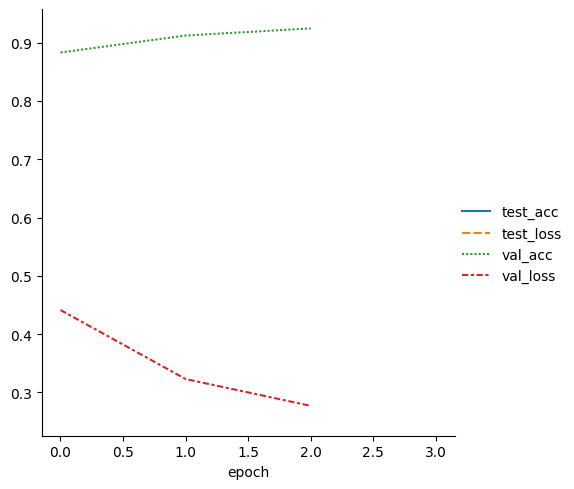

In [11]:
# Read in the training metrics from the CSV file generated by the logger
metrics = pd.read_csv(f"{trainer.logger.log_dir}/metrics.csv")

# Remove the "step" column, which is not needed for our analysis
del metrics["step"]

# Set the epoch column as the index, for easier plotting
metrics.set_index("epoch", inplace=True)

# Display the first few rows of the metrics table, excluding any columns with all NaN values
display(metrics.dropna(axis=1, how="all").head())

# Create a line plot of the training metrics using Seaborn
sn.relplot(data=metrics, kind="line")